In [ ]:
import kagglehub
import os
import ast
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
path = kagglehub.dataset_download("tatheerabbas/psychological-manipulation-conversations-dataset")
file_path = os.path.join(path, "manipulational_conversation.jsonl")

df = pd.read_json(file_path, lines=True)

100%|██████████| 1.28M/1.28M [00:00<00:00, 17.4MB/s]

Extracting files...


In [ ]:
def flatten_messages(messages):
    if isinstance(messages, str):
        try:
            messages = ast.literal_eval(messages)
        except Exception:
            return messages

    if not isinstance(messages, list):
        return ""

    parts = [msg.get("text", "") for msg in messages if isinstance(msg, dict)]
    return " ".join(parts)

df["conversation_text"] = df["messages"].apply(flatten_messages)

In [ ]:
X = df["conversation_text"]
y = df["manipulation_type"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=100
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
svm_model = SVC(
    kernel="linear",
    C=1.0,
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
y_pred = svm_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.9735

                    precision    recall  f1-score   support

    charm_flattery       0.99      0.98      0.99       280
   direct_coercion       0.92      0.97      0.95       280
       gaslighting       0.96      0.95      0.96       280
    guilt_tripping       1.00      0.99      0.99       280
      love_bombing       0.99      0.98      0.99       280
           neutral       0.97      0.97      0.97       320
passive_aggressive       0.99      0.97      0.98       280

          accuracy                           0.97      2000
         macro avg       0.97      0.97      0.97      2000
      weighted avg       0.97      0.97      0.97      2000



### Predict Manipulation Type for a New Conversation

In [ ]:
# new data
new_conversation = ["Can't you give me a single second of your time?"]
new_conversation_tfidf = vectorizer.transform(new_conversation)
predicted_type = svm_model.predict(new_conversation_tfidf)

print(f"The predicted manipulation type is: {predicted_type[0]}")

The predicted manipulation type is: direct_coercion


Metrics
Macro F1 Score: 0.9737
Weighted F1 Score: 0.9734
Micro F1 Score: 0.9735
Accuracy: 0.9735

📋 PER-CLASS METRICS:
------------------------------------------------------------
 Manipulation Type  Precision   Recall  F1-Score  Support
    charm_flattery   0.989209 0.982143  0.985663      280
   direct_coercion   0.919192 0.975000  0.946274      280
       gaslighting   0.956989 0.953571  0.955277      280
    guilt_tripping   1.000000 0.985714  0.992806      280
      love_bombing   0.989209 0.982143  0.985663      280
           neutral   0.974763 0.965625  0.970173      320
passive_aggressive   0.989091 0.971429  0.980180      280
------------------------------------------------------------

🔍 DETECTABILITY ANALYSIS:
------------------------------------------------------------
Most detectable: guilt_tripping (F1 = 0.9928)
Least detectable: direct_coercion (F1 = 0.9463)


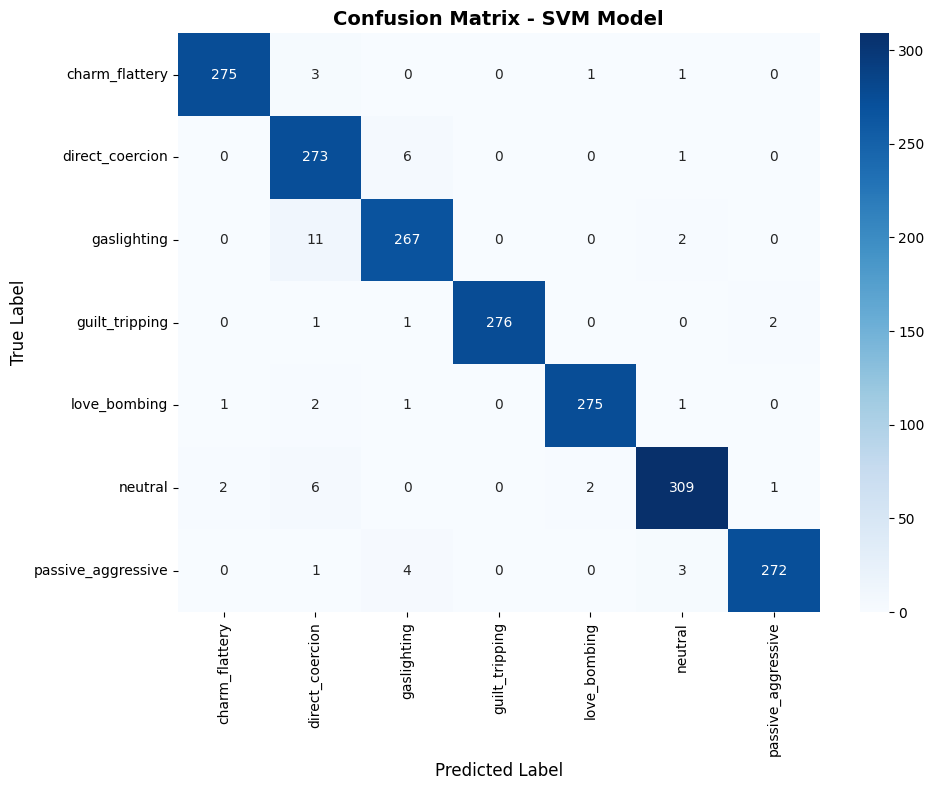

Saved: visualizations/confusion_matrix.png


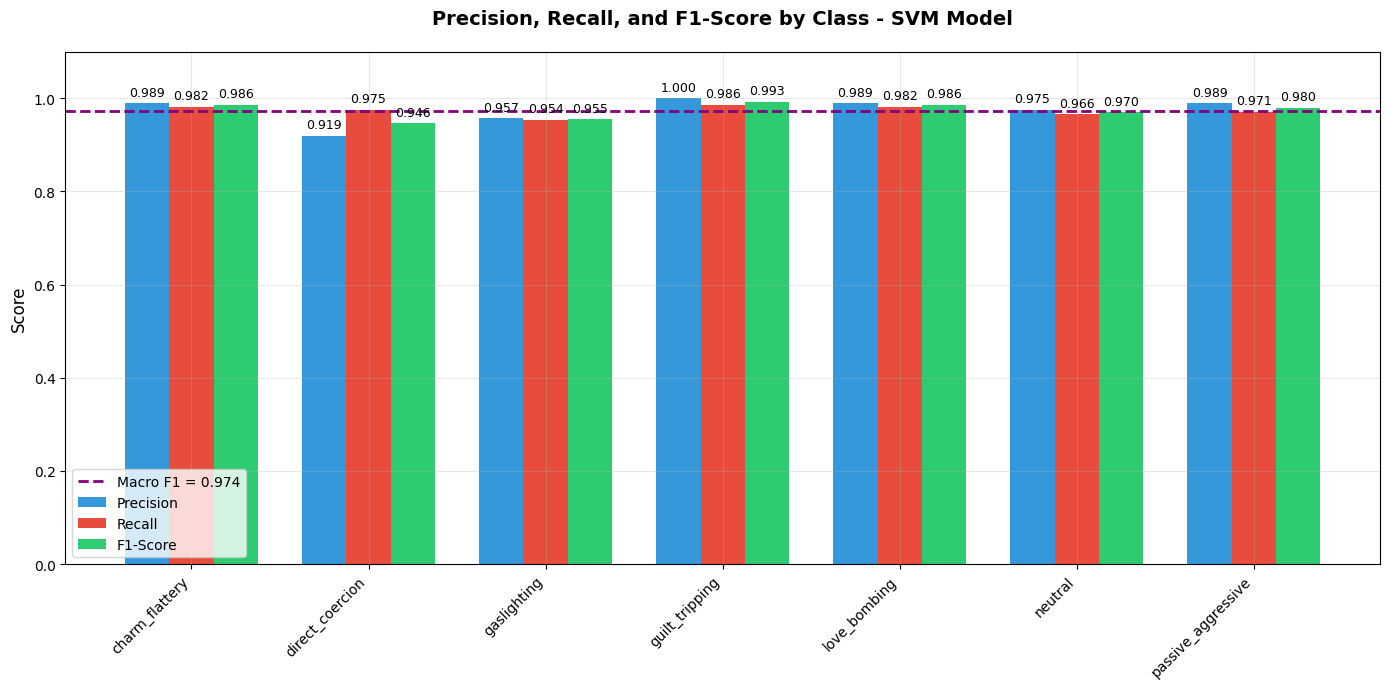

Saved: visualizations/precision_recall_f1.png


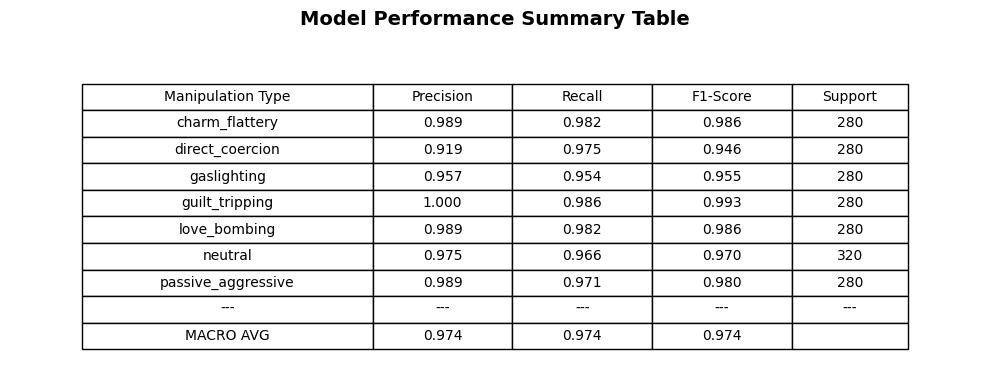

Saved: visualizations/metrics_summary_table.png

📁 ALL VISUALIZATIONS SAVED IN 'visualizations/' FOLDER
Files created:
  1. confusion_matrix.png
  2. precision_recall_f1.png
  3. metrics_summary_table.png

✅ Metrics also saved to 'visualizations/model_performance_metrics.csv'


In [ ]:
import sklearn
# eval metrics and visualizations
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('visualizations', exist_ok=True)

y_pred = svm_model.predict(X_test_tfidf)

# macro f1
macro_f1 = f1_score(y_pred, y_test, average='macro')
weighted_f1 = f1_score(y_pred, y_test, average='weighted')
micro_f1 = f1_score(y_pred, y_test, average='micro')

print("="*60)
print("Metrics")
print("="*60)
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Weighted F1 Score: {weighted_f1:.4f}")
print(f"Micro F1 Score: {micro_f1:.4f}")
print(f"Accuracy: {sklearn.metrics.accuracy_score(y_test, y_pred):.4f}")
print("="*60)

# per class precision, recall, f1
print("\n📋 PER-CLASS METRICS:")
print("-"*60)
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=sorted(y_test.unique())
)

class_metrics = pd.DataFrame({
    'Manipulation Type': sorted(y_test.unique()),
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
print(class_metrics.to_string(index=False))
print("-"*60)

# easy/hard classes
print("\n🔍 DETECTABILITY ANALYSIS:")
print("-"*60)
best_class = class_metrics.loc[class_metrics['F1-Score'].idxmax()]
worst_class = class_metrics.loc[class_metrics['F1-Score'].idxmin()]

print(f"Most detectable: {best_class['Manipulation Type']} (F1 = {best_class['F1-Score']:.4f})")
print(f"Least detectable: {worst_class['Manipulation Type']} (F1 = {worst_class['F1-Score']:.4f})")

classes = class_metrics['Manipulation Type']
f1_scores = class_metrics['F1-Score']

# confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()),
            ax=ax)
ax.set_title('Confusion Matrix - SVM Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('visualizations/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: visualizations/confusion_matrix.png")


# precision vs recall vs F1
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(classes))
width = 0.25
bars1 = ax.bar(x - width, class_metrics['Precision'], width, label='Precision', color='#3498db')
bars2 = ax.bar(x, class_metrics['Recall'], width, label='Recall', color='#e74c3c')
bars3 = ax.bar(x + width, class_metrics['F1-Score'], width, label='F1-Score', color='#2ecc71')

ax.axhline(y=macro_f1, color='purple', linestyle='--', linewidth=2, label=f'Macro F1 = {macro_f1:.3f}')

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_title('Precision, Recall, and F1-Score by Class - SVM Model', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1) # inc y-axis for overlap
ax.legend()
ax.grid(True, alpha=0.3)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('visualizations/precision_recall_f1.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: visualizations/precision_recall_f1.png")


# Metrics summary
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table_data = []
for _, row in class_metrics.iterrows():
    table_data.append([row['Manipulation Type'],
                       f"{row['Precision']:.3f}",
                       f"{row['Recall']:.3f}",
                       f"{row['F1-Score']:.3f}",
                       row['Support']])

table_data.append(['---', '---', '---', '---', '---'])
table_data.append(['MACRO AVG', f"{precision.mean():.3f}", f"{recall.mean():.3f}", f"{macro_f1:.3f}", ''])

column_labels = ['Manipulation Type', 'Precision', 'Recall', 'F1-Score', 'Support']
table = ax.table(cellText=table_data, colLabels=column_labels, cellLoc='center', loc='center',
                  colWidths=[0.25, 0.12, 0.12, 0.12, 0.10])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax.set_title('Model Performance Summary Table', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('visualizations/metrics_summary_table.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: visualizations/metrics_summary_table.png")

print("\n" + "="*60)
print("📁 ALL VISUALIZATIONS SAVED IN 'visualizations/' FOLDER")
print("="*60)
print("Files created:")
print("  1. confusion_matrix.png")
print("  2. precision_recall_f1.png")
print("  3. metrics_summary_table.png")
print("="*60)

class_metrics.to_csv('visualizations/model_performance_metrics.csv', index=False)
print("\n✅ Metrics also saved to 'visualizations/model_performance_metrics.csv'")